## Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Dataset

### Load

In [5]:
X = np.load("data/X.npy")
y = np.load("data/y.npy")

X = X[0:1000]
y = y[0:1000]

### View the variables

In [6]:
print(f"First element of X is: {X[0]}")

First element of X is: [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  

In [7]:
print(f"The first element of y is: {y[0,0]}")
print(f"The last element of y is: {y[-1,0]}")

The first element of y is: 0
The last element of y is: 1


### Dimension of variables

In [8]:
print(f"Shape of X is: {X.shape}")
print(f"Shape of y is: {y.shape}")

Shape of X is: (1000, 400)
Shape of y is: (1000, 1)


### Visualizing the data

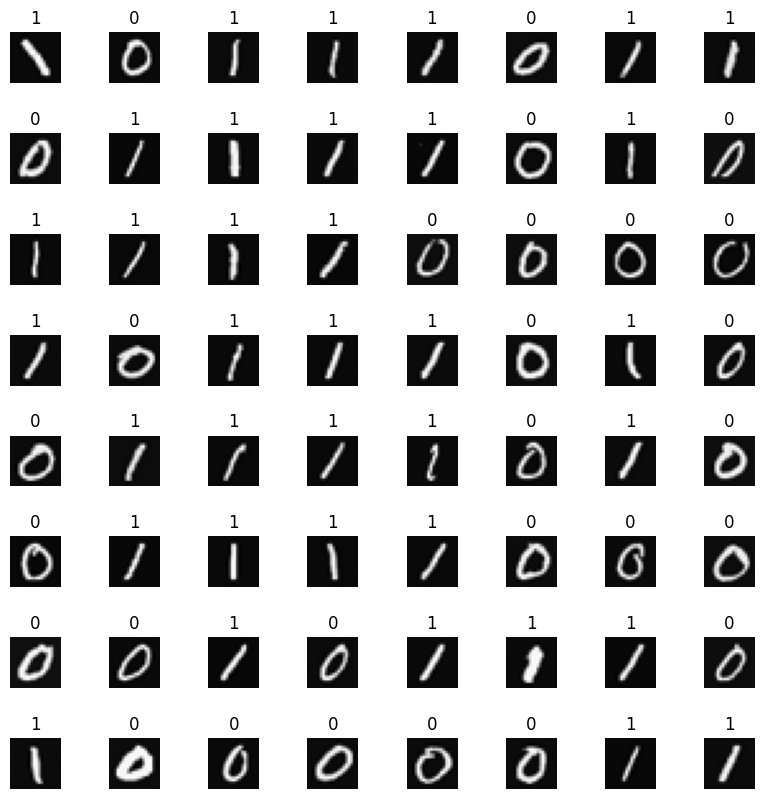

In [14]:
m,n = X.shape

fig,axes = plt.subplots(8,8,figsize=(8,8))

# pad controls the outer edge, h_pad controls the vertical space between rows
fig.tight_layout(pad=0.5, h_pad=1.5)

for i,ax in enumerate(axes.flat):
    # select random indices
    random_index=np.random.randint(m)

    # Select the row corresponding random index
    # and reshape the imgae
    X_random_reshaped = X[random_index].reshape((20,20)).T

    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Display the label of the image
    ax.set_title(y[random_index, 0])

    ax.set_axis_off()

## Models

### Tensorflow model implementation
- Keras Sequential model
- Dense Layer
- Sigmoid activation

In [16]:
model = Sequential(
    [
        tf.keras.Input(shape=(400,)),

        tf.keras.layers.Dense(units=25, activation='sigmoid', name="layer1"),
        tf.keras.layers.Dense(units=15, activation='sigmoid', name="layer2"),
        tf.keras.layers.Dense(units=1, activation='sigmoid', name="layer3"),
    ],
    name="my_model"
)

#### Model summary

In [17]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,431 (40.75 KB)

 Trainable params: 10,431 (40.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Extract params

In [24]:
[layer1, layer2, layer3]=model.layers

W1,b1=layer1.get_weights()
W2,b2=layer2.get_weights()
W3,b3=layer3.get_weights()

print(f"w1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"w1 shape: {W2.shape}, b1 shape: {b2.shape}")
print(f"w1 shape: {W3.shape}, b1 shape: {b3.shape}")

w1 shape: (400, 25), b1 shape: (25,)
w1 shape: (25, 15), b1 shape: (15,)
w1 shape: (15, 1), b1 shape: (1,)


In [29]:
print(W3)

[[-0.51391625]
 [ 0.13144904]
 [ 0.09455794]
 [ 0.0320856 ]
 [-0.14421129]
 [-0.45555663]
 [-0.01875645]
 [-0.06127328]
 [-0.24428546]
 [ 0.26204807]
 [-0.494751  ]
 [-0.57964486]
 [ 0.36565244]
 [-0.0311597 ]
 [ 0.43642598]]


#### Manual params count

In [27]:
m1,n1 = W1.shape
m2,n2 = W2.shape
m3,n3 = W3.shape

layer1_params = (m1*n1)+n1
layer2_params = (m2*n2)+n2
layer3_params = (m3*n3)+n3
print(f"Layer 1: {layer1_params}")
print(f"Layer 2: {layer2_params}")
print(f"Layer 3: {layer3_params}")
print(f"Total: {layer1_params+layer2_params+layer3_params}")

Layer 1: 10025
Layer 2: 390
Layer 3: 16
Total: 10431


#### Compile and fit
The following code will define a loss function and run gradient descent to fit the weights of the model to the training data. This will be explained in more detail in the following week.

In [30]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001)
)

model.fit(
    X,y,
    epochs=20
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6712
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5110
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3833 
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2812 
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2081 
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1583 
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1245
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1008 
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0835 
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0706 
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0607 
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0530 
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0469
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0420 
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0380 
Epoch 16

#### Predict

In [31]:
prediction=model.predict(X[0].reshape(1,400)) #0
print(f"Predicting a zero: {prediction}")

prediction=model.predict(X[500].reshape(1,400)) #1
print(f"Predicting a one: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicting a zero: [[0.01644522]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicting a one: [[0.9766162]]
